In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import urllib3

# Set the current and parent paths
current_path = os.getcwd()
parent_path = os.path.dirname(current_path)
sys.path.append(parent_path)

# Import custom modules
import funcTidal  # Module for acquiring tidal data from NOAA
import constUnitConvert

# Initialize constants and unit conversion
CONVERT = constUnitConvert.ConstantsUnitConversion()

# Configure matplotlib style
plt.style.use('tableau-colorblind10')

# Disable the InsecureRequestWarning
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


# Tutorial: Obtaining Tidal Data from NOAA Current Prediction Buoys

This tutorial guides users on how to obtain tidal data from NOAA current prediction buoys. Most of the functions required are in the `funcTidal` module.

- Find a list of available station IDs at this site: [NOAA Buoy List](https://tidesandcurrents.noaa.gov/noaacurrents/Stations?g=693)
- The code works only with **Harmonic** predictions.
- More information about the API can be found here: [API Info](https://api.tidesandcurrents.noaa.gov/mdapi/prod/#request)

The following code demonstrates how to load tidal data using the `funcTidal` module.

In [2]:
# Define parameters for tidal data acquisition
mystation = "SEA0712"
mystartdate = 20210101  # Must be in YYYYMMDD format
myrangeHr = 2 * 7 * 24  # Desired time range of data in hours (2 weeks)
mytimestep = 0.2        # Time step in seconds to interpolate data between points

# Load tidal data using the funcTidal module
Uinf, t, dMoor, buoyLatitude, buoyLongitude = funcTidal.loadTidal(mystation, mystartdate, myrangeHr, mytimestep)

# Print the mooring depth
print(f"Mooring depth is {dMoor} [m].")

Mooring depth is 40.8 [m].


# Plotting Tidal Flow Speed Over Time

In this section, we will plot the tidal flow speed over time using the data obtained from the NOAA current prediction buoys.

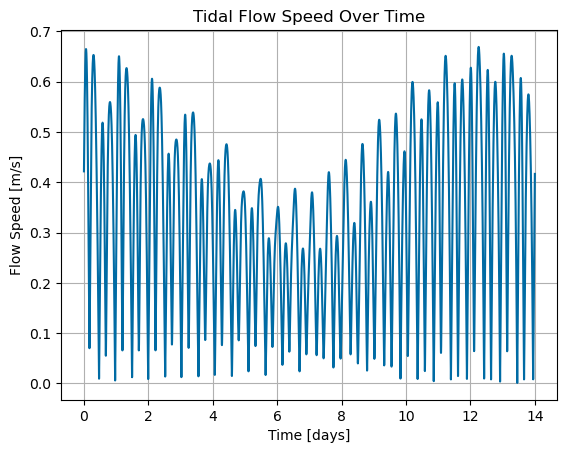

In [3]:
# Plot the flow speed over time
plt.plot(t * CONVERT.sec2days, Uinf)
plt.xlabel("Time [days]")
plt.ylabel("Flow Speed [m/s]")
plt.title("Tidal Flow Speed Over Time")
plt.grid(True)
plt.show()

# Calculating Cable Length and Closest City

In this section, we will calculate the cable length from the buoy to the closest city using the `funcTidal` module. The city coordinates are provided in a text file named `AlaskaCityLatLong.txt`.

- This calculation is used for estimating the cable length.
- `buoyLatitude` and `buoyLongitude`, which are outputs from `funcTidal.loadTidal`, must be provided.


In [4]:
# Calculate the cable length and closest city
dCable, CityName = funcTidal.calCableLen(buoyLatitude, buoyLongitude, "../../TurboShipCostCalculator/AlaskaCityLatLong.txt")

# Convert cable length from meters to miles
cable_length_miles = dCable * CONVERT.m2mile

# Print the cable length and closest city
print(f"Cable length is {round(cable_length_miles, 2)} miles and the closest city is {CityName}.")

Cable length is 2.89 miles and the closest city is Ketchikan.


# Adjusting Flow Speed of Tidal Buoy with Changing Water Depth

This section demonstrates how to adjust the flow speed of the tidal buoy as the water depth changes. The code below shows how to use the `funcTidal` module to calculate the speed at various depths.

- The file also contains functions to adjust the flow speed of the tidal buoy as the water depth changes.
- `Radius`, `hub depth`, and `mooring depth` (from `funcTidal.loadTidal`) must be provided.


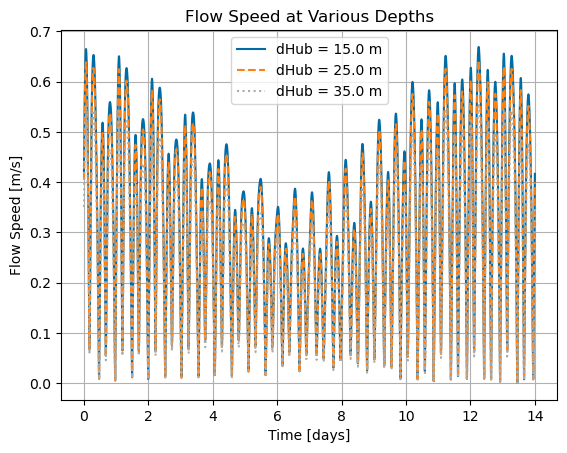

In [5]:
# Define parameters for adjusting flow speed at various depths
Radius = 1.0  # meters
dHub_values = [15.0, 25.0, 35.0]  # meters (example values)
line_styles = ['-', '--', ':']  # example line styles

# Plot flow speed at various depths
for dHub, line_style in zip(dHub_values, line_styles):
    U_depth = funcTidal.flowAtDepth(Uinf, Radius, dHub, dMoor)
    plt.plot(t * CONVERT.sec2days, U_depth, label=f'dHub = {dHub} m', linestyle=line_style)

# Configure plot labels and legend
plt.xlabel("Time [days]")
plt.ylabel("Flow Speed [m/s]")
plt.legend()
plt.title("Flow Speed at Various Depths")
plt.grid(True)
plt.show()


This is an illustrative example on how flow speed changes with depth.

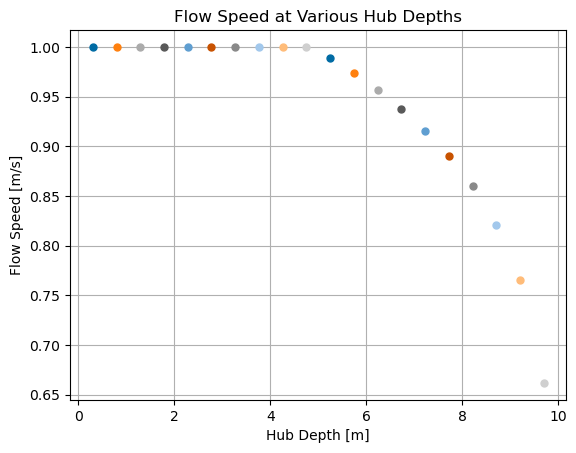

In [6]:
# Define parameters for adjusting flow speed at various hub depths
Radius = 0.2  # meters
dMoor = 10  # meters
UinfIN = 1  # initial flow speed in m/s

# Generate a vector of hub depths
dHubVector = np.linspace(Radius + 0.1, dMoor - Radius - 0.1, 20)

# Plot flow speed at various hub depths
for dHub in dHubVector:
    Unew = funcTidal.flowAtDepth(UinfIN, Radius, dHub, dMoor)
    plt.plot(dHub, Unew, '.', markersize=10)

# Configure plot labels
plt.xlabel('Hub Depth [m]')
plt.ylabel('Flow Speed [m/s]')
plt.title('Flow Speed at Various Hub Depths')
plt.grid(True)
plt.show()
